# Detección de anomalías en las capturas pesqueras argentinas

**Aprendizaje Automático – Grupo 12**

Integrantes:
- Bernal, Alejandro Matias
- Paredes, Sebastian Pablo
- Rodrigues, David Ezequiel
- Barnetche, Iñaki Francisco

---

## 1. Introducción

### Dominio de aplicación
La pesca marítima es una actividad económica relevante para Argentina. Cada mes se registran desembarques en los puertos del litoral marítimo, con especies, flotas y volúmenes muy distintos entre sí. Estos registros son publicados como datos abiertos por el Ministerio de Agricultura, Ganadería y Pesca (MAGyP).

Las capturas varían mucho según la especie, el puerto, el tipo de flota y la época del año. Por eso, un valor alto o bajo no indica por sí solo algo fuera de lo normal: lo habitual para una especie en un puerto puede ser excepcional para otra.

### Objetivo del modelo
Planteamos el problema como una **clasificación binaria**:

> Para cada combinación **especie–puerto**, y utilizando solamente la información disponible hasta el mes *t−1*, predecir si la captura del mes *t* será **normal** o **anómala**.

- **Normal**: la captura está dentro de lo esperable para esa especie, ese puerto y esa época del año.
- **Anómala**: la captura se aparta marcadamente de su comportamiento histórico (caída o aumento).

El modelo no explica *por qué* ocurre la anomalía (causas estacionales, ambientales, económicas, administrativas o de flota); su función es señalar esos casos con anticipación para analizarlos después.

### Beneficios
- Alertar con tiempo sobre caídas inesperadas en la captura de una especie.
- Detectar cambios en la actividad de determinados puertos.
- Ayudar a planificar producción, almacenamiento y transporte.
- Identificar registros que podrían ser incorrectos.
- Orientar investigaciones sobre presión pesquera o cambios ambientales.

## 2. Carga de datos

Fuente: [Datos Abiertos MAGyP – Desembarques de pesca marítima](https://datos.magyp.gob.ar/dataset/http-www-magyp-gob-ar-sitio-areas-pesca-maritima-desembarques). Recurso principal: desembarques 2010–2018.

La celda siguiente intenta, en orden: (1) leer el archivo si ya está en el entorno, (2) descargarlo desde `DATA_URL` si se completa, (3) pedir que se suba manualmente desde la computadora (Colab).

In [ ]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (11, 4.5)
RANDOM_STATE = 42

In [ ]:
ARCHIVO = "desembarques_2010_2018.csv"
# Si se tiene el enlace directo de descarga del CSV (botón "Descargar" del portal), pegarlo aquí:
DATA_URL = "https://datos.magyp.gob.ar/dataset/e2f12522-4dea-495e-877a-b6d2737ae6bf/resource/1996a5ec-7075-4062-9a79-05868fc2a2e2/download/captura-puerto-flota-2010-2018.csv"

def leer_csv(ruta):
    for enc in ("utf-8", "latin-1"):
        try:
            return pd.read_csv(ruta, encoding=enc, sep=None, engine="python")
        except UnicodeDecodeError:
            continue
    raise ValueError("No se pudo leer el archivo")

if os.path.exists(ARCHIVO):
    df_raw = leer_csv(ARCHIVO)
elif DATA_URL:
    df_raw = leer_csv(DATA_URL)
else:
    from google.colab import files
    subido = files.upload()          # seleccionar el CSV descargado del portal
    ARCHIVO = next(iter(subido))
    df_raw = leer_csv(ARCHIVO)

# Normalización de nombres de columnas (minúsculas, sin espacios)
df_raw.columns = (df_raw.columns.str.strip().str.lower()
                  .str.replace(" ", "_").str.replace("í", "i").str.replace("ó", "o"))
print("Dimensiones:", df_raw.shape)
df_raw.head()

Dimensiones: (41340, 13)


,fecha,flota,puerto,provincia,provincia_id,departamento,departamento_id,latitud,longitud,categoria,especie,especie_agrupada,captura
0,2010-01,Costeros,Caleta Cordova,Chubut,26,Escalante,26021,-45.75,-67.38,Peces,Merluza hubbsi,Merluza hubbsi S41,386114
1,2010-01,Costeros,Caleta Cordova,Chubut,26,Escalante,26021,-45.75,-67.38,Peces,Pez gallo,otras especies,4367
2,2010-01,Costeros,Caleta Cordova,Chubut,26,Escalante,26021,-45.75,-67.38,Peces,Rayas nep,Rayas (sin V. Cost),13
3,2010-01,Rada o ría,Caleta Cordova,Chubut,26,Escalante,26021,-45.75,-67.38,Crustáceos,Centolla,Centolla,48218
4,2010-01,Rada o ría,Caleta Cordova,Chubut,26,Escalante,26021,-45.75,-67.38,Peces,Merluza hubbsi,Merluza hubbsi S41,935


## 3. Análisis Exploratorio de Datos (EDA)

### 3.1 Estructura general

In [ ]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41340 entries, 0 to 41339
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   fecha             41340 non-null  object 
 1   flota             41340 non-null  object 
 2   puerto            41340 non-null  object 
 3   provincia         41340 non-null  object 
 4   provincia_id      41340 non-null  int64  
 5   departamento      41340 non-null  object 
 6   departamento_id   41340 non-null  int64  
 7   latitud           38960 non-null  float64
 8   longitud          38960 non-null  float64
 9   categoria         41340 non-null  object 
 10  especie           41340 non-null  object 
 11  especie_agrupada  41340 non-null  object 
 12  captura           41340 non-null  int64  
dtypes: float64(2), int64(3), object(8)
memory usage: 4.1+ MB


In [ ]:
print("Valores únicos por variable:")
df_raw.nunique().to_frame("unicos").T

Valores únicos por variable:


,fecha,flota,puerto,provincia,provincia_id,departamento,departamento_id,latitud,longitud,categoria,especie,especie_agrupada,captura
unicos,108,8,23,6,6,17,18,21,21,4,89,16,19621


In [ ]:
df_raw.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
fecha,41340,108,2010-05,584,NaN,NaN,NaN,NaN,NaN,NaN,NaN
flota,41340,8,Rada o ría,12329,NaN,NaN,NaN,NaN,NaN,NaN,NaN
puerto,41340,23,Mar del Plata,17744,NaN,NaN,NaN,NaN,NaN,NaN,NaN
provincia,41340,6,Buenos Aires,28395,NaN,NaN,NaN,NaN,NaN,NaN,NaN
provincia_id,"41,340.00",NaN,NaN,NaN,21.15,26.03,6.00,6.00,6.00,26.00,99.00
departamento,41340,17,General Pueyrredon,17744,NaN,NaN,NaN,NaN,NaN,NaN,NaN
departamento_id,"41,340.00",NaN,NaN,NaN,"21,465.26","25,885.09","6,056.00","6,357.00","6,357.00","26,021.00","99,999.00"
latitud,"38,960.00",NaN,NaN,NaN,-39.98,3.74,-54.87,-40.73,-38.05,-38.05,-35.75
longitud,"38,960.00",NaN,NaN,NaN,-60.44,3.85,-68.41,-64.93,-57.54,-57.54,-56.75
categoria,41340,4,Peces,36502,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 3.2 Valores faltantes y duplicados

In [ ]:
faltantes = pd.DataFrame({"faltantes": df_raw.isna().sum(),
                          "porcentaje": df_raw.isna().mean() * 100})
display(faltantes[faltantes.faltantes > 0])

dup_exactos = df_raw.duplicated().sum()
claves = ["fecha", "flota", "puerto", "especie"]
dup_clave = df_raw.duplicated(subset=claves).sum()
print(f"Duplicados exactos: {dup_exactos}")
print(f"Registros repetidos por clave (fecha, flota, puerto, especie): {dup_clave}")

,faltantes,porcentaje
latitud,2380,5.76
longitud,2380,5.76


Duplicados exactos: 0
Registros repetidos por clave (fecha, flota, puerto, especie): 6253


In [ ]:
# ¿Los puertos sin coordenadas tienen coordenadas en otros registros?
sin_coord = df_raw[df_raw.latitud.isna() | df_raw.longitud.isna()].puerto.unique()
coords_por_puerto = df_raw.groupby("puerto")[["latitud", "longitud"]].agg(lambda s: s.dropna().nunique())
display(coords_por_puerto.loc[sin_coord].rename(columns=lambda c: f"{c}_valores_distintos"))

,latitud_valores_distintos,longitud_valores_distintos
puerto,,
otros puertos Buenos Aires,0,0
otros puertos,0,0


Los faltantes de coordenadas (5,8 %) corresponden exclusivamente a dos categorías agregadas, **«otros puertos»** y **«otros puertos Buenos Aires»**, que agrupan desembarques de varios puertos menores y no tienen coordenadas en ningún registro. El resto de los puertos tiene coordenadas completas.

No hay duplicados exactos, pero 6.253 registros (15 %) repiten la combinación fecha–flota–puerto–especie con algún otro valor distinto. No se descartan: se consolidan sumando al agregar por especie–puerto–mes (paso 7 del preprocesamiento).

### 3.3 Variable `captura`

count       41,340.00
mean       165,701.49
std        906,552.07
min              1.00
1%              18.00
5%              40.00
25%            420.00
50%          2,811.00
75%         23,125.75
95%        560,790.90
99%      4,006,486.79
max     25,232,438.00
Name: captura, dtype: float64

Capturas = 0: 0 | Capturas < 0: 0
Asimetría: 10.75


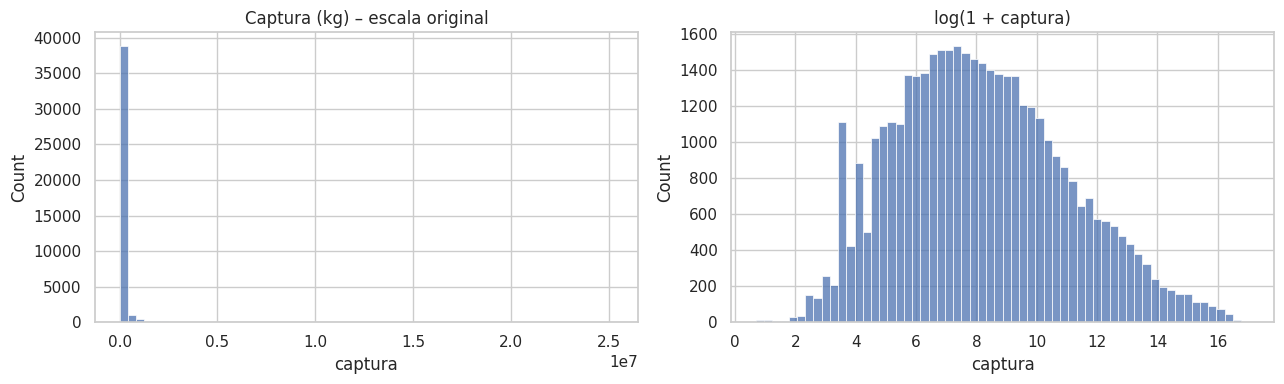

In [ ]:
cap = df_raw["captura"]
print(cap.describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]))
print(f"\nCapturas = 0: {(cap == 0).sum()} | Capturas < 0: {(cap < 0).sum()}")
print(f"Asimetría: {cap.skew():.2f}")

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(cap, bins=60, ax=ax[0]); ax[0].set_title("Captura (kg) – escala original")
sns.histplot(np.log1p(cap.clip(lower=0)), bins=60, ax=ax[1]); ax[1].set_title("log(1 + captura)")
plt.tight_layout(); plt.show()

La captura tiene una distribución extremadamente asimétrica: unos pocos registros concentran volúmenes enormes. En escala logarítmica la distribución se vuelve aproximadamente simétrica, por lo que **trabajaremos con `log1p(captura)`** para comparar especies de magnitudes muy distintas.

### 3.4 Variables categóricas

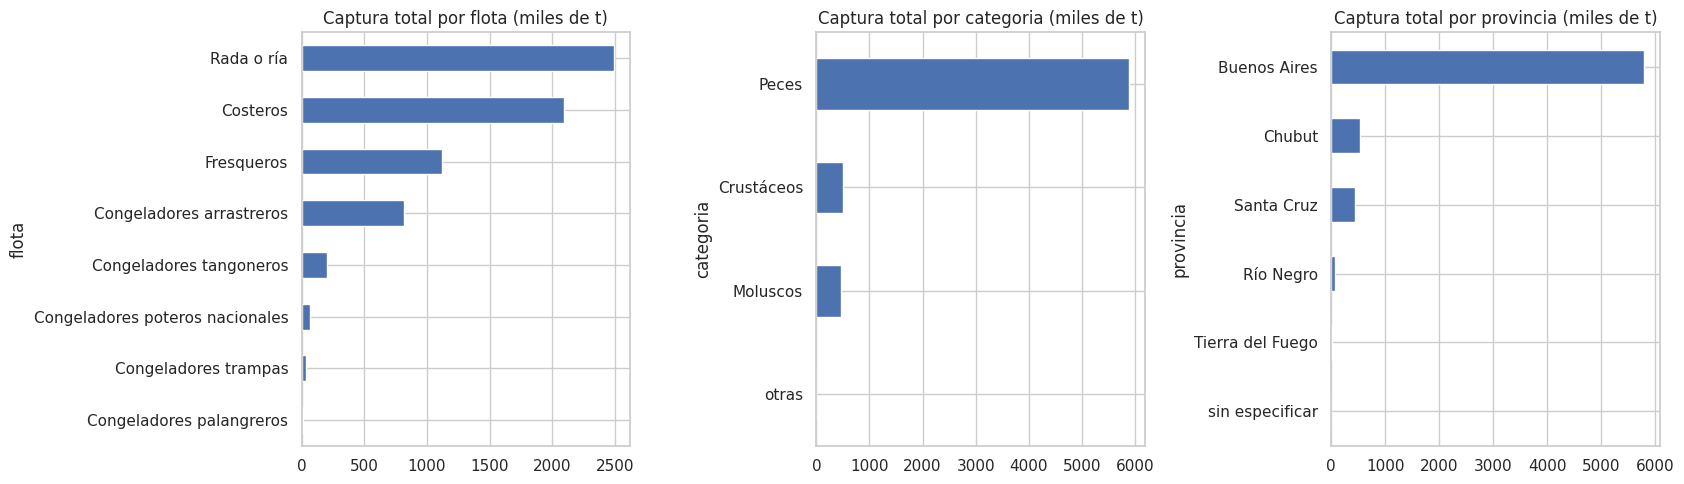

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(17, 5))
for a, col in zip(ax, ["flota", "categoria", "provincia"]):
    t = df_raw.groupby(col).captura.sum().sort_values() / 1e6
    t.plot.barh(ax=a); a.set_title(f"Captura total por {col} (miles de t)"); a.set_xlabel("")
plt.tight_layout(); plt.show()

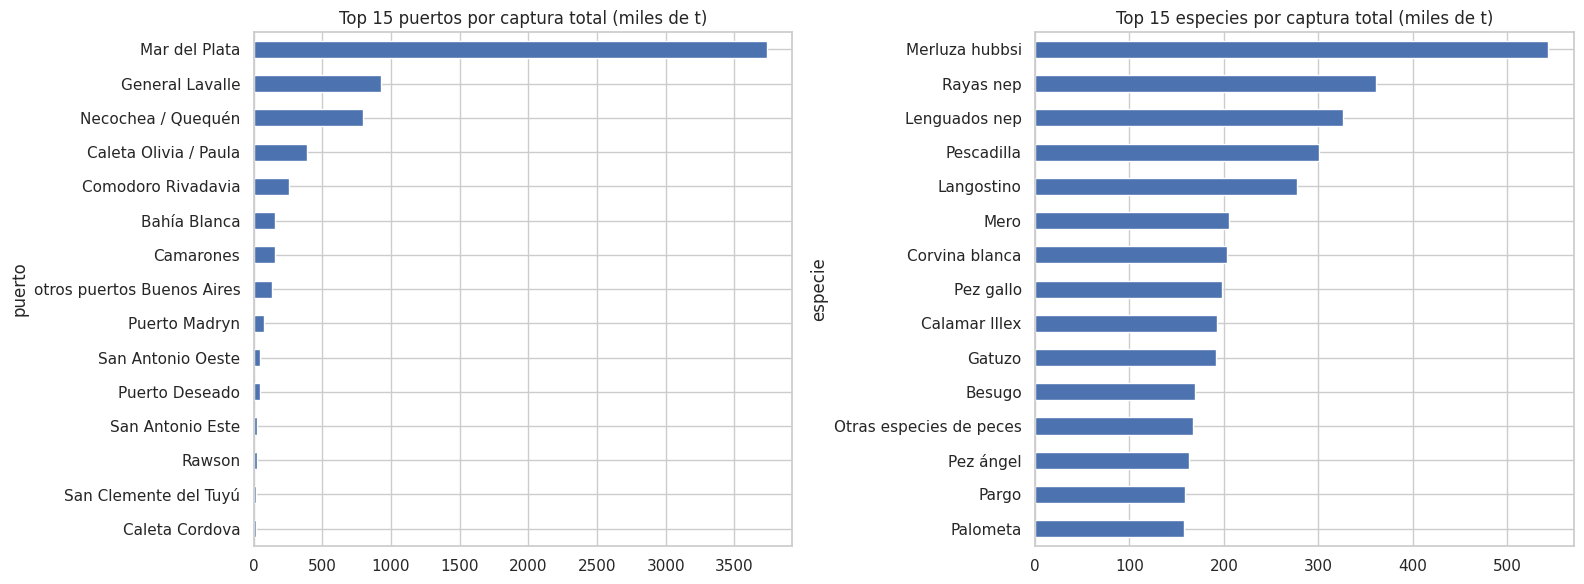

Las 5 especies principales concentran el 26.4% de la captura total.


In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))
(df_raw.groupby("puerto").captura.sum().nlargest(15).sort_values() / 1e6).plot.barh(ax=ax[0])
ax[0].set_title("Top 15 puertos por captura total (miles de t)")
(df_raw.groupby("especie").captura.sum().nlargest(15).sort_values() / 1e6).plot.barh(ax=ax[1])
ax[1].set_title("Top 15 especies por captura total (miles de t)")
plt.tight_layout(); plt.show()

cuota = df_raw.groupby("especie").captura.sum().sort_values(ascending=False)
print(f"Las 5 especies principales concentran el {cuota.head(5).sum() / cuota.sum():.1%} de la captura total.")

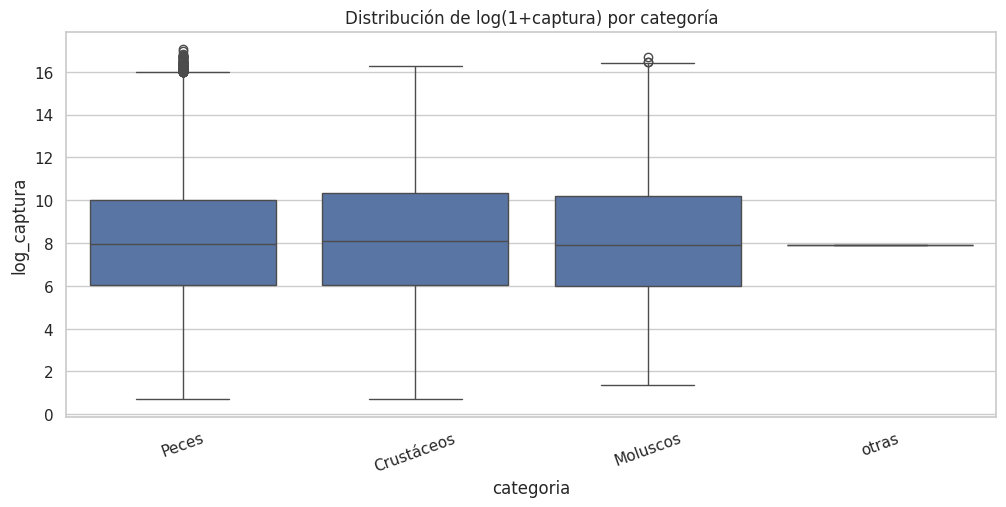

In [ ]:
plt.figure(figsize=(12, 5))
sns.boxplot(data=df_raw.assign(log_captura=np.log1p(df_raw.captura.clip(lower=0))),
            x="categoria", y="log_captura")
plt.title("Distribución de log(1+captura) por categoría"); plt.xticks(rotation=20); plt.show()

### 3.5 Dimensión temporal y estacionalidad

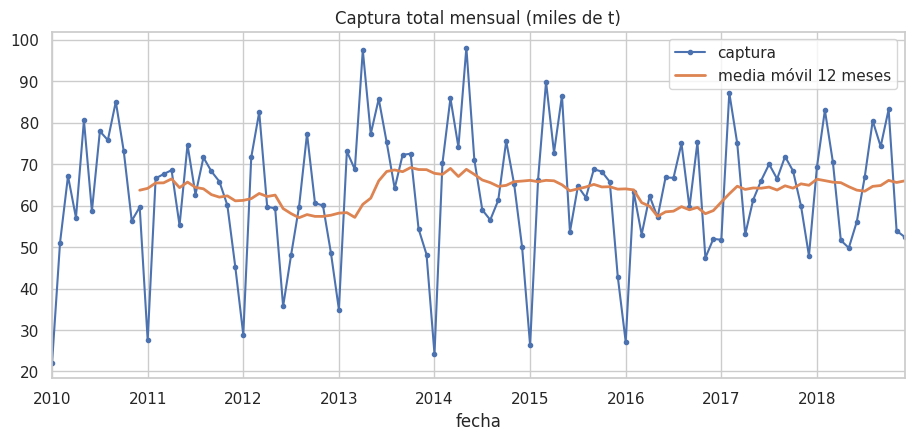

In [ ]:
df_eda = df_raw.copy()
df_eda["fecha"] = pd.to_datetime(df_eda["fecha"].astype(str).str[:7], format="%Y-%m")
df_eda["anio"], df_eda["mes"] = df_eda.fecha.dt.year, df_eda.fecha.dt.month

mensual = df_eda.groupby("fecha").captura.sum() / 1e6
ax = mensual.plot(marker=".", title="Captura total mensual (miles de t)")
mensual.rolling(12).mean().plot(ax=ax, lw=2, label="media móvil 12 meses"); ax.legend(); plt.show()

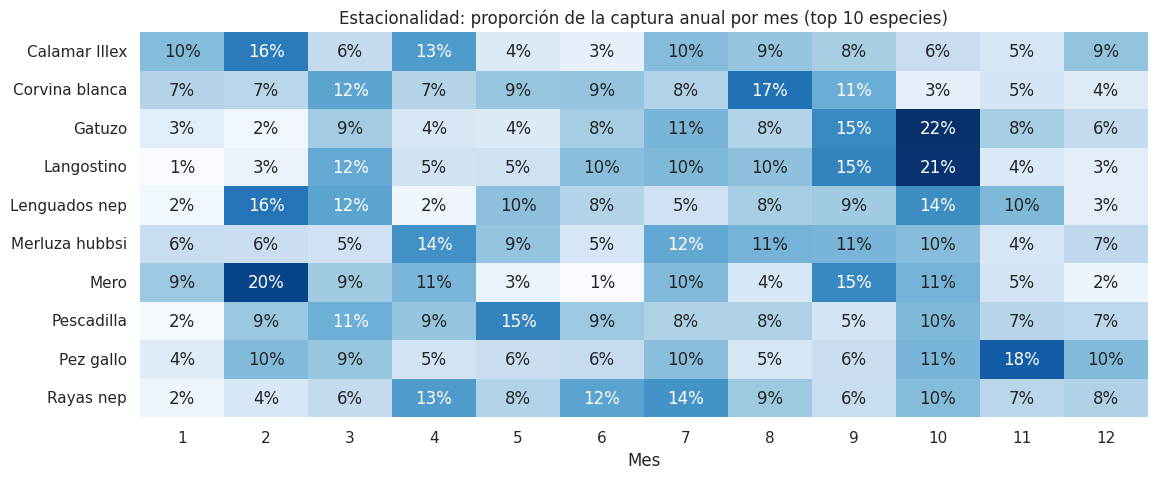

In [ ]:
top_esp = df_eda.groupby("especie").captura.sum().nlargest(10).index
piv = (df_eda[df_eda.especie.isin(top_esp)]
       .groupby(["especie", "anio", "mes"]).captura.sum()
       .groupby(["especie", "mes"]).mean().unstack())
piv_norm = piv.div(piv.sum(axis=1), axis=0)  # proporción del año en cada mes
plt.figure(figsize=(13, 5))
sns.heatmap(piv_norm, cmap="Blues", annot=True, fmt=".0%", cbar=False)
plt.title("Estacionalidad: proporción de la captura anual por mes (top 10 especies)")
plt.xlabel("Mes"); plt.ylabel(""); plt.show()

Cada especie tiene un patrón estacional propio (zafras). Esto confirma que **una anomalía debe definirse respecto al mismo mes en años anteriores y para la misma serie especie–puerto**, no con un umbral global.

### 3.6 Continuidad de las series especie–puerto

Series especie–puerto: 719
       n_meses  cobertura
count   719.00     719.00
mean     29.21       0.54
std      35.44       0.37
min       1.00       0.02
25%       2.00       0.18
50%      10.00       0.50
75%      50.00       1.00
max     108.00       1.00


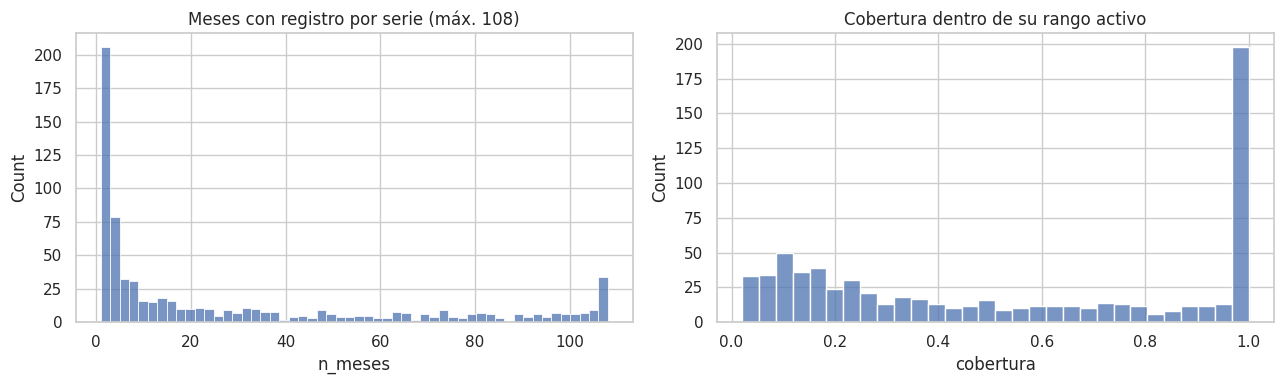

In [ ]:
serie = df_eda.groupby(["especie", "puerto"]).fecha.agg(n_meses="nunique", inicio="min", fin="max")
serie["meses_rango"] = ((serie.fin.dt.year - serie.inicio.dt.year) * 12 + serie.fin.dt.month - serie.inicio.dt.month + 1)
serie["cobertura"] = serie.n_meses / serie.meses_rango
print(f"Series especie–puerto: {len(serie):,}")
print(serie[["n_meses", "cobertura"]].describe())

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(serie.n_meses, bins=54, ax=ax[0]); ax[0].set_title("Meses con registro por serie (máx. 108)")
sns.histplot(serie.cobertura, bins=30, ax=ax[1]); ax[1].set_title("Cobertura dentro de su rango activo")
plt.tight_layout(); plt.show()

Muchas series tienen muy pocos meses con registros (especies ocasionales o puertos con baja actividad). Con tan poca historia no es posible estimar un comportamiento "habitual", por lo que se filtrarán en el preprocesamiento.

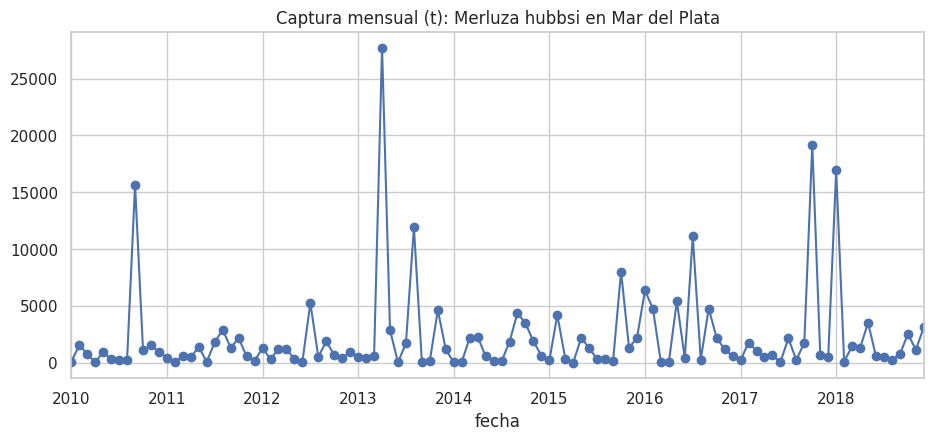

In [ ]:
# Ejemplo: una serie relevante
ej = df_eda.groupby(["especie", "puerto"]).captura.sum().idxmax()
s = df_eda[(df_eda.especie == ej[0]) & (df_eda.puerto == ej[1])].groupby("fecha").captura.sum() / 1e3
s.plot(marker="o", title=f"Captura mensual (t): {ej[0]} en {ej[1]}"); plt.show()

In [ ]:
# Relación entre flota y puerto: ¿cuántas flotas operan en una misma serie?
flotas_por_serie = df_eda.groupby(["especie", "puerto", "fecha"]).flota.nunique()
print(flotas_por_serie.value_counts(normalize=True).sort_index().rename("proporción"))

flota
1   0.56
2   0.25
3   0.15
4   0.03
5   0.00
Name: proporción, dtype: float64


### 3.7 Conclusiones del EDA
- La captura es muy asimétrica y abarca varios órdenes de magnitud: conviene usar escala logarítmica.
- Hay una fuerte concentración de la captura en pocas especies, puertos y flotas.
- Cada especie presenta una estacionalidad marcada y distinta, por lo que la comparación debe hacerse por serie y por mes del año.
- Las coordenadas presentan faltantes, pero cada puerto tiene coordenadas fijas: se pueden completar desde otros registros del mismo puerto.
- Muchas series tienen historia insuficiente; hay meses sin registro que deben interpretarse.
- No existe una etiqueta de anomalía: hay que construirla a partir del histórico.

## 4. Limpieza y preprocesamiento (con justificación)

| Paso | Decisión | Justificación |
|---|---|---|
| 1 | Normalizar textos (espacios, mayúsculas) | Evita que un mismo puerto/especie aparezca como categorías distintas. |
| 2 | Eliminar duplicados exactos | Son copias del mismo registro y sobrestimarían la captura. |
| 3 | Convertir `fecha` a datetime y derivar `anio` y `mes` | El mes captura la estacionalidad; el año, la tendencia. |
| 4 | Completar `latitud`/`longitud` con la moda del mismo puerto | Las coordenadas son propias del puerto, no del registro. |
| 5 | Descartar `provincia_id`, `departamento`, `departamento_id` | Redundantes con `provincia`/`puerto`; no aportan información nueva. |
| 6 | Eliminar capturas negativas o nulas | No tienen sentido físico (errores de carga). |
| 7 | Agregar por mes–especie–puerto (sumando flotas) | La unidad de análisis del problema es la serie especie–puerto. Se conserva la flota dominante y el nº de flotas como predictoras. |
| 8 | Completar meses faltantes con captura 0 dentro del rango activo de cada serie | Un mes sin desembarque en una serie activa es información (captura nula), no un dato faltante. |
| 9 | Filtrar series con menos de 36 meses con captura | Sin historia suficiente no se puede definir lo "normal" para esa serie. |
| 10 | Transformar `captura` con `log1p` | Reduce la asimetría y permite comparar series de distinta escala. |
| 11 | Construir la etiqueta `anomalia` y las predictoras con información hasta *t−1* | Evita fuga de información (*data leakage*). |

In [ ]:
df = df_raw.copy()
n0 = len(df)

# 1. Normalización de textos
cat_cols = ["flota", "puerto", "provincia", "categoria", "especie", "especie_agrupada"]
for c in cat_cols:
    df[c] = df[c].astype(str).str.strip().str.replace(r"\s+", " ", regex=True).str.title()

# 2. Duplicados exactos
df = df.drop_duplicates()
n_dup = n0 - len(df)

# 3. Fechas
df["fecha"] = pd.to_datetime(df["fecha"].astype(str).str[:7], format="%Y-%m")
df["anio"], df["mes"] = df.fecha.dt.year, df.fecha.dt.month

# 4. Coordenadas: moda por puerto
for c in ["latitud", "longitud"]:
    moda = df.groupby("puerto")[c].agg(lambda s: s.mode().iloc[0] if s.notna().any() else np.nan)
    df[c] = df[c].fillna(df.puerto.map(moda))

# 5. Columnas redundantes
df = df.drop(columns=[c for c in ["provincia_id", "departamento", "departamento_id"] if c in df])

# 6. Capturas inválidas
df["captura"] = pd.to_numeric(df["captura"], errors="coerce")
n_inv = int((df.captura.isna() | (df.captura < 0)).sum())
df = df[df.captura.notna() & (df.captura >= 0)]

print(f"Registros iniciales: {n0:,} | duplicados eliminados: {n_dup:,} | capturas inválidas eliminadas: {n_inv:,}")
print("Faltantes restantes en coordenadas:", df[["latitud", "longitud"]].isna().sum().to_dict())

Registros iniciales: 41,340 | duplicados eliminados: 0 | capturas inválidas eliminadas: 0
Faltantes restantes en coordenadas: {'latitud': 2380, 'longitud': 2380}


In [ ]:
# 7. Agregación a la unidad de análisis: (especie, puerto, mes)
por_flota = df.groupby(["especie", "puerto", "fecha", "flota"], as_index=False).captura.sum()
flota_dom = (por_flota.sort_values("captura", ascending=False)
             .drop_duplicates(["especie", "puerto", "fecha"])
             [["especie", "puerto", "fecha", "flota"]].rename(columns={"flota": "flota_principal"}))
agg = (df.groupby(["especie", "puerto", "fecha"], as_index=False)
         .agg(captura=("captura", "sum"), n_flotas=("flota", "nunique")))
agg = agg.merge(flota_dom, on=["especie", "puerto", "fecha"])

# Atributos estáticos de especie y puerto
attr_esp = df.groupby("especie")[["categoria", "especie_agrupada"]].agg(lambda s: s.mode().iloc[0])
attr_pto = df.groupby("puerto")[["provincia", "latitud", "longitud"]].agg(lambda s: s.mode().iloc[0] if s.notna().any() else np.nan)

# 8. Completar meses sin registro dentro del rango activo de cada serie
def completar(g):
    rango = pd.date_range(g.fecha.min(), g.fecha.max(), freq="MS")
    return g.set_index("fecha").reindex(rango).rename_axis("fecha").reset_index()

agg = (agg.groupby(["especie", "puerto"], group_keys=True)[["fecha", "captura", "n_flotas", "flota_principal"]]
          .apply(completar).reset_index(level=[0, 1]).reset_index(drop=True))
agg["sin_registro"] = agg.captura.isna().astype(int)
agg["captura"] = agg.captura.fillna(0)
agg["n_flotas"] = agg.n_flotas.fillna(0).astype(int)
agg["flota_principal"] = agg.groupby(["especie", "puerto"]).flota_principal.transform(
    lambda s: s.fillna(s.mode().iloc[0]))

# 9. Filtro de series con historia suficiente
MIN_MESES = 36
meses_activos = agg[agg.captura > 0].groupby(["especie", "puerto"]).size()
validas = meses_activos[meses_activos >= MIN_MESES].index
n_series_tot = agg.groupby(["especie", "puerto"]).ngroups
agg = agg.set_index(["especie", "puerto"]).loc[validas].reset_index()
print(f"Series totales: {n_series_tot:,} | series con >= {MIN_MESES} meses activos: {len(validas):,}")

# 10. Transformación logarítmica
agg["log_captura"] = np.log1p(agg.captura)
agg["anio"], agg["mes"] = agg.fecha.dt.year, agg.fecha.dt.month
agg = agg.join(attr_esp, on="especie").join(attr_pto, on="puerto")
agg = agg.sort_values(["especie", "puerto", "fecha"]).reset_index(drop=True)
print("Dimensiones tras agregación:", agg.shape)

Series totales: 719 | series con >= 36 meses activos: 221
Dimensiones tras agregación: (23080, 15)


### 4.1 Construcción de la etiqueta `anomalia`

Para cada serie especie–puerto y cada mes *t*:

1. **Valor esperado** $\hat{y}_t$: mediana de `log_captura` del **mismo mes calendario en los años anteriores** (al menos 2 años previos). Esto incorpora la estacionalidad.
2. **Dispersión habitual** $s_t$: desvío absoluto mediano (MAD) de los residuos $y - \hat{y}$ de la serie en los 24 meses anteriores, escalado por 1,4826 (equivalente robusto al desvío estándar), con un piso de 0,25 para evitar divisiones por valores muy chicos en series muy estables.
3. **Puntaje robusto**: $z_t = (y_t - \hat{y}_t)/s_t$.
4. **Etiqueta**: `anomalia = 1` si $|z_t| > 3$; además se registra el sentido (`caida` o `aumento`).

Todo se calcula usando solo información **previa** a *t*, de modo que la definición es coherente con el uso real del sistema. Los primeros dos años de cada serie quedan sin etiqueta (sirven como historia).

In [ ]:
K, PISO, MIN_ANIOS = 3.0, 0.25, 2

g = agg.groupby(["especie", "puerto", "mes"]).log_captura
agg["esperado"] = g.transform(lambda s: s.shift(1).expanding(min_periods=MIN_ANIOS).median())
agg["residuo"] = agg.log_captura - agg.esperado

gs = agg.groupby(["especie", "puerto"]).residuo
agg["escala"] = gs.transform(
    lambda s: s.shift(1).rolling(24, min_periods=12).apply(lambda x: np.median(np.abs(x - np.median(x))), raw=True)
) * 1.4826
agg["escala"] = agg.escala.clip(lower=PISO)
agg["z"] = agg.residuo / agg.escala

agg["anomalia"] = (agg.z.abs() > K).astype("Int64")
agg.loc[agg.z.isna(), "anomalia"] = pd.NA
agg["tipo_anomalia"] = np.select([agg.z > K, agg.z < -K], ["aumento", "caida"], "normal")
agg.loc[agg.z.isna(), "tipo_anomalia"] = np.nan

et = agg.dropna(subset=["anomalia"])
print(f"Meses etiquetados: {len(et):,}")
print(et.tipo_anomalia.value_counts(normalize=True).rename("proporción"))

Meses etiquetados: 12,472
tipo_anomalia
normal    0.94
caida     0.03
aumento   0.02
Name: proporción, dtype: float64


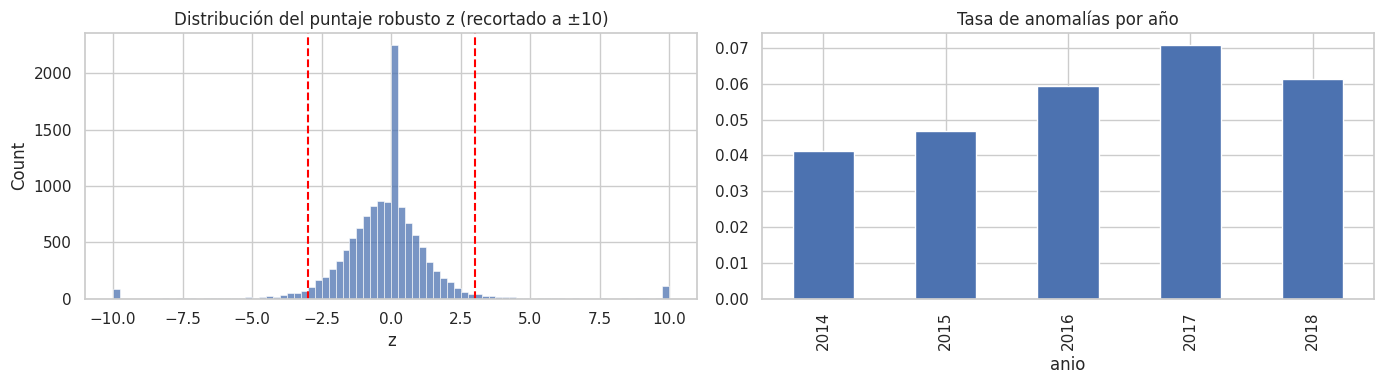

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(et.z.clip(-10, 10), bins=80, ax=ax[0])
for v in (-K, K): ax[0].axvline(v, color="red", ls="--")
ax[0].set_title("Distribución del puntaje robusto z (recortado a ±10)")
et.groupby("anio").anomalia.mean().plot.bar(ax=ax[1], title="Tasa de anomalías por año")
plt.tight_layout(); plt.show()

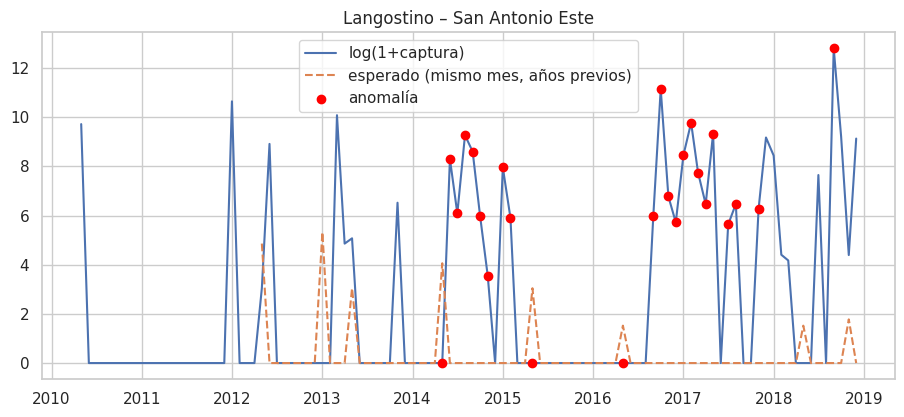

In [ ]:
# Visualización de la etiqueta sobre una serie
ej_s = et.groupby(["especie", "puerto"]).anomalia.sum().idxmax()
s = agg[(agg.especie == ej_s[0]) & (agg.puerto == ej_s[1])]
plt.plot(s.fecha, s.log_captura, label="log(1+captura)")
plt.plot(s.fecha, s.esperado, ls="--", label="esperado (mismo mes, años previos)")
a = s[s.anomalia == 1]
plt.scatter(a.fecha, a.log_captura, color="red", zorder=3, label="anomalía")
plt.title(f"{ej_s[0]} – {ej_s[1]}"); plt.legend(); plt.show()

### 4.2 Variables predictoras (solo información hasta *t−1*)

Como el objetivo es **anticipar** la anomalía, ninguna predictora usa el valor del mes *t*:

- Rezagos de `log_captura`: *t−1, t−2, t−3, t−12*.
- Medias y desvíos móviles de 3, 6 y 12 meses (sobre *t−1* hacia atrás).
- Valor esperado del mes *t* (`esperado`, calculado con años anteriores) y su diferencia con el último valor observado.
- Anomalía en *t−1* y cantidad de anomalías en los 12 meses previos.
- Proporción de meses sin desembarque en los últimos 12 meses.
- Calendario: mes (codificado con seno/coseno) y año.
- Contexto: categoría, especie agrupada, provincia, puerto, flota principal, nº de flotas en *t−1*.

In [ ]:
gb = agg.groupby(["especie", "puerto"])
y_prev = gb.log_captura.shift(1)
agg["lag_1"] = y_prev
agg["lag_2"] = gb.log_captura.shift(2)
agg["lag_3"] = gb.log_captura.shift(3)
agg["lag_12"] = gb.log_captura.shift(12)
for w in (3, 6, 12):
    agg[f"media_{w}"] = y_prev.groupby([agg.especie, agg.puerto]).transform(lambda s: s.rolling(w, min_periods=2).mean())
    agg[f"std_{w}"] = y_prev.groupby([agg.especie, agg.puerto]).transform(lambda s: s.rolling(w, min_periods=2).std())
agg["dif_esperado_lag1"] = agg.esperado - agg.lag_1
agg["dif_lag1_lag12"] = agg.lag_1 - agg.lag_12
an_num = agg.anomalia.astype("float")
agg["anomalia_lag1"] = an_num.groupby([agg.especie, agg.puerto]).shift(1)
agg["anomalias_12m"] = an_num.groupby([agg.especie, agg.puerto]).transform(lambda s: s.shift(1).rolling(12, min_periods=1).sum())
agg["prop_sin_desembarque_12m"] = (agg.captura == 0).astype(float).groupby([agg.especie, agg.puerto]).transform(
    lambda s: s.shift(1).rolling(12, min_periods=1).mean())
agg["n_flotas_lag1"] = gb.n_flotas.shift(1)
agg["mes_sin"] = np.sin(2 * np.pi * agg.mes / 12)
agg["mes_cos"] = np.cos(2 * np.pi * agg.mes / 12)

FEATURES_NUM = ["lag_1", "lag_2", "lag_3", "lag_12", "media_3", "std_3", "media_6", "std_6",
                "media_12", "std_12", "esperado", "dif_esperado_lag1", "dif_lag1_lag12",
                "anomalia_lag1", "anomalias_12m", "prop_sin_desembarque_12m", "n_flotas_lag1",
                "mes_sin", "mes_cos", "anio", "latitud", "longitud"]
FEATURES_CAT = ["categoria", "especie_agrupada", "provincia", "puerto", "flota_principal"]
TARGET = "anomalia"

df_limpio = agg.dropna(subset=[TARGET, "lag_1"]).copy()
df_limpio[TARGET] = df_limpio[TARGET].astype(int)
cols_final = (["fecha", "especie", "puerto"] + FEATURES_CAT[:3] + ["flota_principal", "captura", "log_captura",
              "z", "tipo_anomalia", TARGET] + [c for c in FEATURES_NUM if c not in ("latitud", "longitud")]
              + ["latitud", "longitud", "mes"])
cols_final = list(dict.fromkeys(cols_final))
df_limpio = df_limpio[cols_final].reset_index(drop=True)
df_limpio.head()

,fecha,especie,puerto,categoria,especie_agrupada,provincia,flota_principal,captura,log_captura,z,tipo_anomalia,anomalia,lag_1,lag_2,lag_3,lag_12,media_3,std_3,media_6,std_6,media_12,std_12,esperado,dif_esperado_lag1,dif_lag1_lag12,anomalia_lag1,anomalias_12m,prop_sin_desembarque_12m,n_flotas_lag1,mes_sin,mes_cos,anio,latitud,longitud,mes
0,2014-01-01,Abadejo,Mar Del Plata,Peces,Abadejo,Buenos Aires,Fresqueros,680.00,6.52,-1.44,normal,0,9.53,11.27,8.37,13.04,9.72,1.46,10.02,2.73,10.95,2.15,11.03,1.50,-3.51,NaN,NaN,0.00,3.00,0.50,0.87,2014,-38.05,-57.54,1
1,2014-02-01,Abadejo,Mar Del Plata,Peces,Abadejo,Buenos Aires,Rada O Ría,"116,925.00",11.67,-0.07,normal,0,6.52,9.53,11.27,11.07,9.11,2.40,8.61,1.63,10.41,2.39,11.91,5.38,-4.54,0.00,0.00,0.00,2.00,0.87,0.50,2014,-38.05,-57.54,2
2,2014-03-01,Abadejo,Mar Del Plata,Peces,Abadejo,Buenos Aires,Congeladores Arrastreros,"13,778,127.00",16.44,1.25,normal,0,11.67,6.52,9.53,12.20,9.24,2.58,9.27,1.96,10.46,2.41,12.15,0.48,-0.53,0.00,0.00,0.00,4.00,1.00,0.00,2014,-38.05,-57.54,3
3,2014-04-01,Abadejo,Mar Del Plata,Peces,Abadejo,Buenos Aires,Congeladores Arrastreros,"1,230.00",7.12,-1.03,normal,0,16.44,11.67,6.52,12.18,11.54,4.96,10.63,3.42,10.81,2.94,10.64,-5.80,4.26,0.00,0.00,0.00,3.00,0.87,-0.50,2014,-38.05,-57.54,4
4,2014-05-01,Abadejo,Mar Del Plata,Peces,Abadejo,Buenos Aires,Fresqueros,"1,176.00",7.07,-1.11,normal,0,7.12,16.44,11.67,10.85,11.74,4.66,10.42,3.62,10.39,3.09,10.90,3.79,-3.74,0.00,0.00,0.00,3.00,0.50,-0.87,2014,-38.05,-57.54,5


## 5. Descripción del dataset luego de la limpieza y el preprocesamiento

In [ ]:
print(f"Dimensiones: {df_limpio.shape[0]:,} filas x {df_limpio.shape[1]} columnas")
print(f"Período etiquetado: {df_limpio.fecha.min():%Y-%m} a {df_limpio.fecha.max():%Y-%m}")
print(f"Series especie–puerto: {df_limpio.groupby(['especie', 'puerto']).ngroups:,}")
print(f"Especies: {df_limpio.especie.nunique()} | Puertos: {df_limpio.puerto.nunique()} | Flotas principales: {df_limpio.flota_principal.nunique()}")
print(f"\nDistribución de la clase objetivo:")
print(df_limpio[TARGET].value_counts().rename({0: "normal", 1: "anómala"}).to_frame("n")
      .assign(proporcion=lambda d: d.n / d.n.sum()))
print("\nFaltantes por columna (solo las que tienen):")
f = df_limpio.isna().sum(); print(f[f > 0])

Dimensiones: 12,472 filas x 35 columnas
Período etiquetado: 2014-01 a 2018-12
Series especie–puerto: 221
Especies: 62 | Puertos: 17 | Flotas principales: 8

Distribución de la clase objetivo:
              n  proporcion
anomalia                   
normal    11776        0.94
anómala     696        0.06

Faltantes por columna (solo las que tienen):
anomalia_lag1    221
anomalias_12m    221
latitud          927
longitud         927
dtype: int64


In [ ]:
diccionario = pd.DataFrame({
    "variable": df_limpio.columns,
    "tipo": df_limpio.dtypes.astype(str).values,
    "rol": ["clave" if c in ("fecha", "especie", "puerto") else
            "objetivo" if c == TARGET else
            "auxiliar (no usar como predictora)" if c in ("captura", "log_captura", "z", "tipo_anomalia") else
            "predictora" for c in df_limpio.columns],
})
diccionario

,variable,tipo,rol
0,fecha,datetime64[ns],clave
1,especie,object,clave
2,puerto,object,clave
3,categoria,object,predictora
4,especie_agrupada,object,predictora
5,provincia,object,predictora
6,flota_principal,object,predictora
7,captura,float64,auxiliar (no usar como predictora)
8,log_captura,float64,auxiliar (no usar como predictora)
9,z,float64,auxiliar (no usar como predictora)


In [ ]:
df_limpio[FEATURES_NUM].describe().T

,count,mean,std,min,25%,50%,75%,max
lag_1,"12,472.00",6.42,4.96,0.00,0.00,7.24,10.35,17.21
lag_2,"12,472.00",6.40,4.97,0.00,0.00,7.22,10.35,17.21
lag_3,"12,472.00",6.40,4.97,0.00,0.00,7.22,10.35,17.21
lag_12,"12,472.00",6.61,4.93,0.00,0.00,7.45,10.49,17.14
media_3,"12,472.00",6.41,4.10,0.00,3.01,6.78,9.56,15.98
std_3,"12,472.00",2.74,2.08,0.00,1.06,2.48,4.20,9.44
media_6,"12,472.00",6.41,3.68,0.00,3.57,6.50,9.14,14.93
std_6,"12,472.00",3.27,1.64,0.00,2.11,3.28,4.47,8.66
media_12,"12,472.00",6.47,3.35,0.00,3.87,6.42,8.90,14.11
std_12,"12,472.00",3.58,1.31,0.00,2.65,3.64,4.48,7.50


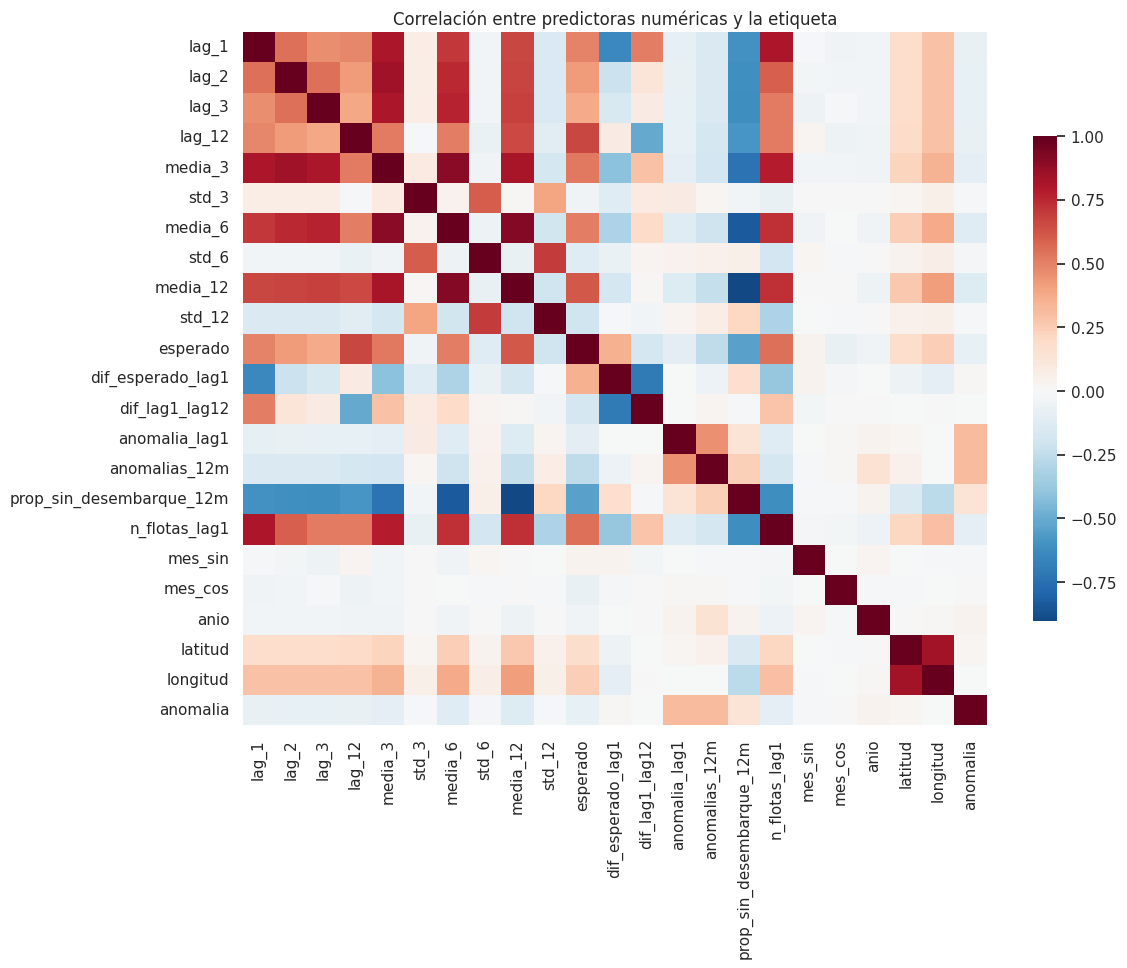

In [ ]:
plt.figure(figsize=(12, 9))
sns.heatmap(df_limpio[FEATURES_NUM + [TARGET]].corr(), cmap="RdBu_r", center=0, cbar_kws={"shrink": .7})
plt.title("Correlación entre predictoras numéricas y la etiqueta"); plt.show()

Las variables `captura`, `log_captura`, `z` y `tipo_anomalia` se conservan en el archivo para interpretación y auditoría, pero **no deben usarse como predictoras**, porque contienen el valor del mes que se quiere anticipar.

Las clases están **desbalanceadas** (las anomalías son minoría, como es esperable por definición), lo que condiciona la elección del modelo y de las métricas.

## 6. Acceso al dataset limpio

La siguiente celda exporta el dataset limpio a CSV, lo descarga y, opcionalmente, lo guarda en Google Drive.

**Enlace al dataset limpio:** `https://drive.google.com/drive/folders/18GkGOAWwEB6ezbwMCQ4pHu1aaVPmFjiZ?usp=sharing`

In [ ]:
SALIDA = "desembarques_limpio_anomalias.csv"
df_limpio.to_csv(SALIDA, index=False, encoding="utf-8")
print(f"Archivo generado: {SALIDA} ({os.path.getsize(SALIDA) / 1e6:.1f} MB)")

GUARDAR_EN_DRIVE = False   # cambiar a True para copiarlo a Drive y luego compartir el enlace
try:
    from google.colab import files, drive
    if GUARDAR_EN_DRIVE:
        drive.mount("/content/drive")
        destino = "/content/drive/MyDrive/" + SALIDA
        df_limpio.to_csv(destino, index=False)
        print("Guardado en Drive:", destino)
    files.download(SALIDA)
except ImportError:
    pass  # fuera de Colab el archivo queda en el directorio actual

Archivo generado: desembarques_limpio_anomalias.csv (5.4 MB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 7. Modelo de Aprendizaje Automático a utilizar

### Elección: **Gradient Boosting sobre árboles (HistGradientBoostingClassifier / LightGBM)**, con Regresión Logística como línea base

**Justificación:**

1. **Tipo de problema.** Es clasificación binaria supervisada con datos tabulares y una etiqueta construida. Los métodos de boosting sobre árboles son el estado del arte práctico para este tipo de datos.
2. **Relaciones no lineales e interacciones.** Lo "normal" depende de la combinación especie × puerto × mes × flota. Los árboles capturan esas interacciones sin tener que diseñarlas a mano; un modelo lineal no.
3. **Escalas heterogéneas y valores faltantes.** Los árboles no requieren escalar variables y `HistGradientBoosting` maneja de forma nativa los faltantes que quedan en rezagos y ventanas móviles al inicio de cada serie.
4. **Variables categóricas.** Soporta categorías nativamente (puerto, flota, especie agrupada), evitando un *one-hot* de alta dimensión.
5. **Desbalance de clases.** Permite ponderar la clase minoritaria (`class_weight="balanced"`) y ajustar el umbral de decisión según el costo de no detectar una anomalía.
6. **Interpretabilidad suficiente.** La importancia por permutación (o SHAP) permite explicar qué señales anticipan una anomalía.

**Alternativas consideradas y descartadas como modelo principal:**
- *Regresión Logística*: interpretable y rápida; se usa como **línea base** para medir cuánto aporta un modelo no lineal.
- *Random Forest*: buena opción, pero en general inferior al boosting en precisión y más pesado en memoria.
- *Modelos no supervisados (Isolation Forest, autoencoders)*: detectan rarezas del momento, pero no **anticipan** el mes siguiente ni aprovechan la etiqueta construida.
- *ARIMA/Prophet por serie*: enfoque de regresión; requiere ajustar cientos de modelos y no comparte información entre series.

**Esquema de validación:** partición **temporal** (entrenamiento hasta 2016, validación 2017, prueba 2018) para respetar el orden cronológico y evitar fuga de información.

**Métricas:** por el desbalance, no se usa la *accuracy*; se priorizan **PR-AUC**, **recall** de la clase anómala, **F1** y ROC-AUC.

A continuación se realiza una prueba preliminar para verificar que el planteo es viable (la optimización de hiperparámetros y el análisis de errores quedan para la próxima entrega).

In [ ]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import average_precision_score, roc_auc_score, f1_score, classification_report

X = df_limpio[FEATURES_NUM + FEATURES_CAT].copy()
for c in FEATURES_CAT:
    X[c] = X[c].astype("category")
y = df_limpio[TARGET]
anio = df_limpio.fecha.dt.year
anio_fin = anio.max()
tr, va, te = anio <= anio_fin - 2, anio == anio_fin - 1, anio == anio_fin
print(f"Entrenamiento: {tr.sum():,} | Validación: {va.sum():,} | Prueba: {te.sum():,}")

# Línea base: regresión logística
pre = make_column_transformer(
    (make_pipeline(SimpleImputer(strategy="median"), StandardScaler()), FEATURES_NUM),
    (OneHotEncoder(handle_unknown="ignore"), FEATURES_CAT))
logreg = make_pipeline(pre, LogisticRegression(max_iter=2000, class_weight="balanced"))
logreg.fit(X[tr], y[tr])

# Modelo propuesto: gradient boosting
hgb = HistGradientBoostingClassifier(categorical_features="from_dtype", class_weight="balanced",
                                     learning_rate=0.05, max_iter=400, early_stopping=True,
                                     random_state=RANDOM_STATE)
hgb.fit(X[tr], y[tr])

def evaluar(nombre, modelo, mask):
    p = modelo.predict_proba(X[mask])[:, 1]
    return {"modelo": nombre, "PR-AUC": average_precision_score(y[mask], p),
            "ROC-AUC": roc_auc_score(y[mask], p), "F1 (umbral 0,5)": f1_score(y[mask], p >= .5)}

res = pd.DataFrame([{"modelo": "Azar (prevalencia)", "PR-AUC": y[va].mean(), "ROC-AUC": .5, "F1 (umbral 0,5)": np.nan},
                    evaluar("Regresión logística", logreg, va),
                    evaluar("Gradient Boosting", hgb, va)])
print("Resultados preliminares sobre el conjunto de validación:")
res

Entrenamiento: 7,659 | Validación: 2,561 | Prueba: 2,252
Resultados preliminares sobre el conjunto de validación:


,modelo,PR-AUC,ROC-AUC,"F1 (umbral 0,5)"
0,Azar (prevalencia),0.07,0.50,NaN
1,Regresión logística,0.32,0.75,0.26
2,Gradient Boosting,0.33,0.80,0.30


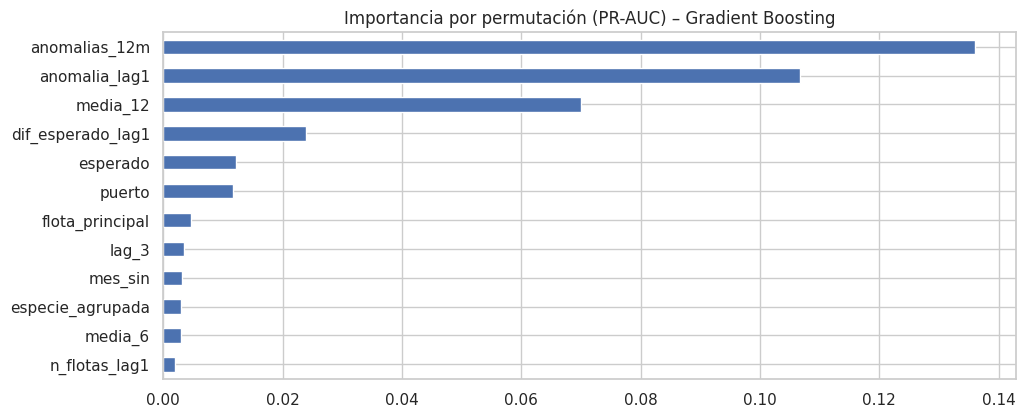

In [ ]:
from sklearn.inspection import permutation_importance
muestra = X[va].sample(min(5000, va.sum()), random_state=RANDOM_STATE).index
imp = permutation_importance(hgb, X.loc[muestra], y.loc[muestra], scoring="average_precision",
                             n_repeats=5, random_state=RANDOM_STATE)
pd.Series(imp.importances_mean, index=X.columns).sort_values().tail(12).plot.barh(
    title="Importancia por permutación (PR-AUC) – Gradient Boosting"); plt.show()

### Próximos pasos
- Ajustar hiperparámetros del modelo (validación temporal) y el umbral de decisión según el costo de errores.
- Evaluar la sensibilidad de la definición de anomalía (valor de *K*, piso de dispersión, mínimo de historia).
- Incorporar los datos de 2019 como conjunto de prueba fuera de muestra.
- Analizar por separado caídas y aumentos, y revisar los falsos positivos con especialistas del dominio.